In [1]:
from itertools import chain

import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
from sccoda.util import cell_composition_data as dat
from sccoda.util import comp_ana as mod
from sccoda.util import data_visualization as viz

import warnings
warnings.filterwarnings("ignore")

sc.logging.print_header()

2026-05-12 15:07:17.637939: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 15:07:17.847528: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-12 15:07:21.427273: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/cluster/pixstor/warrenwc-lab/users/evan/.conda/envs/scanpy/lib/python3.11/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/m

Package,Version
anndata,0.12.7
matplotlib,3.10.8
numpy,2.3.5
pandas,2.3.3
scanpy,1.11.5
seaborn,0.13.2
scCODA,0.1.9
Component,Info
Python,"3.11.14 | packaged by conda-forge | (main, Jan 26 2026, 23:48:32) [GCC 14.3.0]"
OS,Linux-4.18.0-553.8.1.el8_10.x86_64-x86_64-with-glibc2.28


In [2]:
%matplotlib inline
matplotlib.rcParams["figure.figsize"] = (9.0, 9.0)

In [3]:
adata = sc.read_h5ad('total_lung_cell_type.h5ad')
adata

AnnData object with n_obs × n_vars = 37608 × 2706
    obs: 'sample_id', 'population', 'n_genes_by_counts', 'n_genes', 'percent_ribo', 'percent_mito', 'n_counts', 'leiden', 'cell type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'population_colors', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

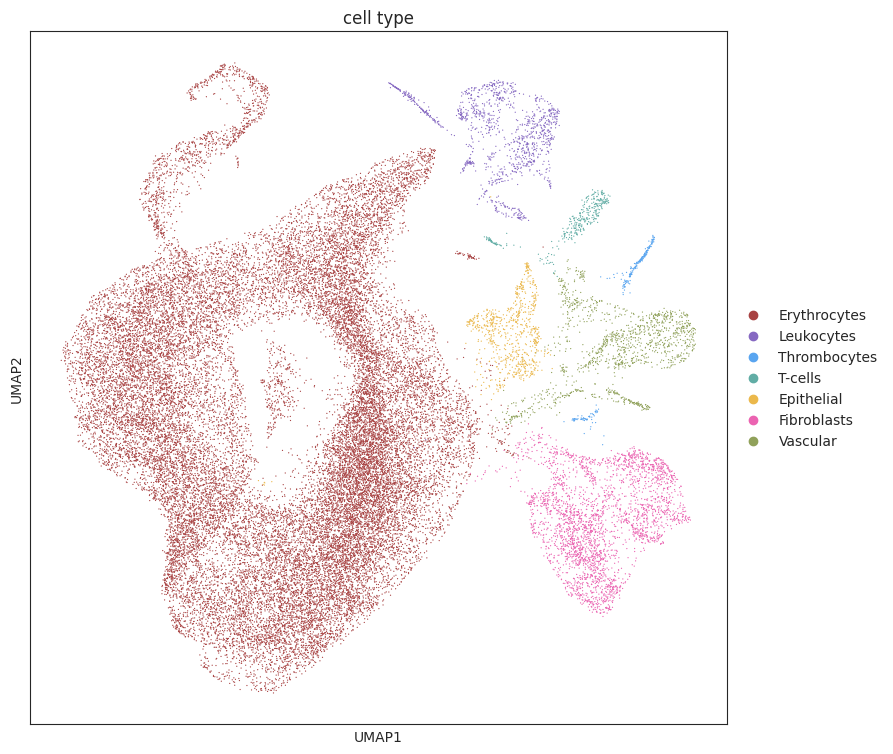

In [4]:
sc.pl.umap(adata, color=["cell type"],)

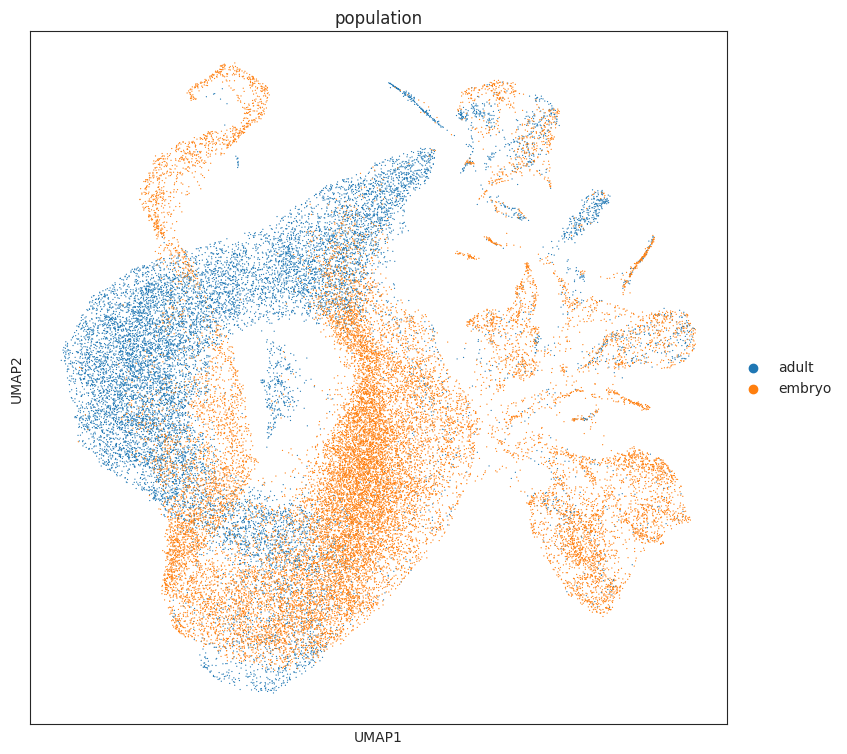

In [5]:
sc.pl.umap(adata, color=["population"],)

In [6]:
data = dat.from_scanpy(adata, "cell type", "sample_id")
data.obs

No covariate information specified!


""
sample_id
C1_GEX
C3_GEX
C4_GEX
E2_GEX
E3_GEX
E4_GEX


In [42]:
palette={"Erythrocytes": "#A84242", 
                   "T-cells": "#61ADA5", 
                   "Thrombocytes": "#59A5F0", 
                   "Epithelial": "#EBB84B", 
                   "Fibroblasts": "#EB63B1", 
                   "Vascular": "#90A15A", 
                   "Leukocytes": "#8669c2"}

type_order = list(data.var.index)
color_list = [palette[t] for t in type_order]

cmap = ListedColormap(color_list, name='celltype_cmap')

In [8]:
data.obs["condition"] = ["adult", "adult", "adult", "embryo", "embryo", "embryo"]
data.obs["condition"] = data.obs["condition"].astype("category")
data.obs["condition"] = data.obs["condition"].cat.reorder_categories(["embryo", "adult"], ordered=True)
data.obs

,condition
sample_id,
C1_GEX,adult
C3_GEX,adult
C4_GEX,adult
E2_GEX,embryo
E3_GEX,embryo
E4_GEX,embryo


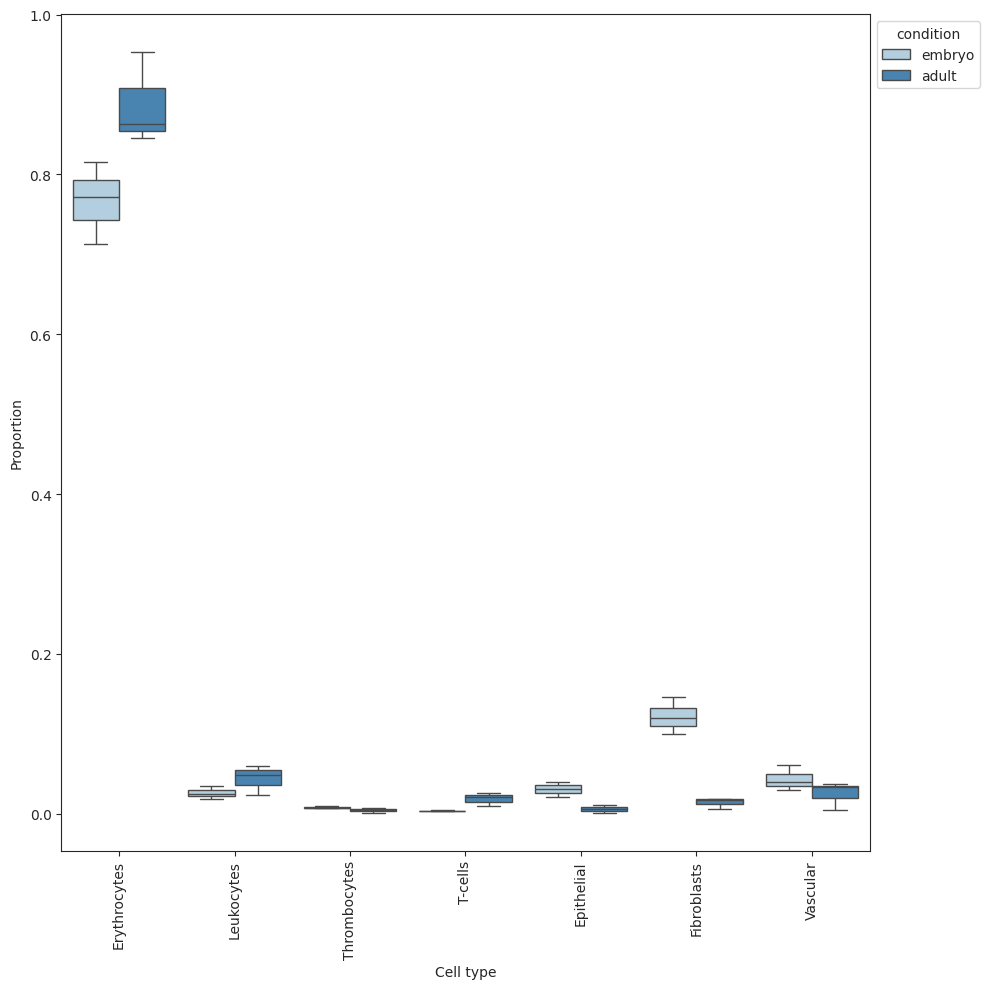

In [9]:
viz.boxplots(data, feature_name="condition", figsize=(10,10))  # Adjust height here
plt.savefig("composition_difference_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
model = mod.CompositionalAnalysis(data, formula="condition")
model

Automatic reference selection! Reference cell type set to Thrombocytes


2026-05-12 15:07:53.463595: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [11]:
sim_results = model.sample_hmc()
sim_results

2026-05-12 15:07:55.481581: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f935c007300 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-05-12 15:07:55.481600: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
  0%|          | 0/20000 [00:00<?, ?it/s]2026-05-12 15:07:55.563012: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778616476.198725 2680083 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 20000/20000 [01:20<00:00, 249.11it/s]


MCMC sampling finished. (101.484 sec)
Acceptance rate: 54.4%


Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [12]:
sim_results.summary()

Compositional Analysis summary:

Data: 6 samples, 7 cell types
Reference index: 2
Formula: condition

Intercepts:
              Final Parameter  Expected Sample
Cell Type                                     
Erythrocytes            4.790      4833.128121
Leukocytes              1.558       190.804469
Thrombocytes            0.179        48.050339
T-cells                 0.107        44.712325
Epithelial              1.469       174.556624
Fibroblasts             2.913       739.703316
Vascular                1.775       237.044807


Effects:
                                 Final Parameter  Expected Sample  \
Covariate          Cell Type                                        
condition[T.adult] Erythrocytes         0.000000      5522.077081   
                   Leukocytes           0.000000       218.003115   
                   Thrombocytes         0.000000        54.899781   
                   T-cells              0.000000        51.085942   
                   Epithelial         

In [13]:
sim_results.set_fdr(0.20)
sim_results.summary()

Compositional Analysis summary:

Data: 6 samples, 7 cell types
Reference index: 2
Formula: condition

Intercepts:
              Final Parameter  Expected Sample
Cell Type                                     
Erythrocytes            4.790      4833.128121
Leukocytes              1.558       190.804469
Thrombocytes            0.179        48.050339
T-cells                 0.107        44.712325
Epithelial              1.469       174.556624
Fibroblasts             2.913       739.703316
Vascular                1.775       237.044807


Effects:
                                 Final Parameter  Expected Sample  \
Covariate          Cell Type                                        
condition[T.adult] Erythrocytes         0.000000      5583.505636   
                   Leukocytes           0.000000       220.428220   
                   Thrombocytes         0.000000        55.510495   
                   T-cells              0.947882       133.280244   
                   Epithelial         

In [34]:
print(data.var_names.tolist)

<bound method IndexOpsMixin.tolist of Index(['Erythrocytes', 'Leukocytes', 'Thrombocytes', 'T-cells', 'Epithelial',
       'Fibroblasts', 'Vascular'],
      dtype='object', name='cell type')>


In [40]:
order = data.var_names.tolist()
new_order = ['Erythrocytes', 'Vascular', 'Thrombocytes', 'Fibroblasts', 'T-cells', 'Epithelial', 'Leukocytes']
reordered_data = data[:, new_order]
print(reordered_data)

View of AnnData object with n_obs × n_vars = 6 × 7
    obs: 'condition'
    var: 'n_cells'


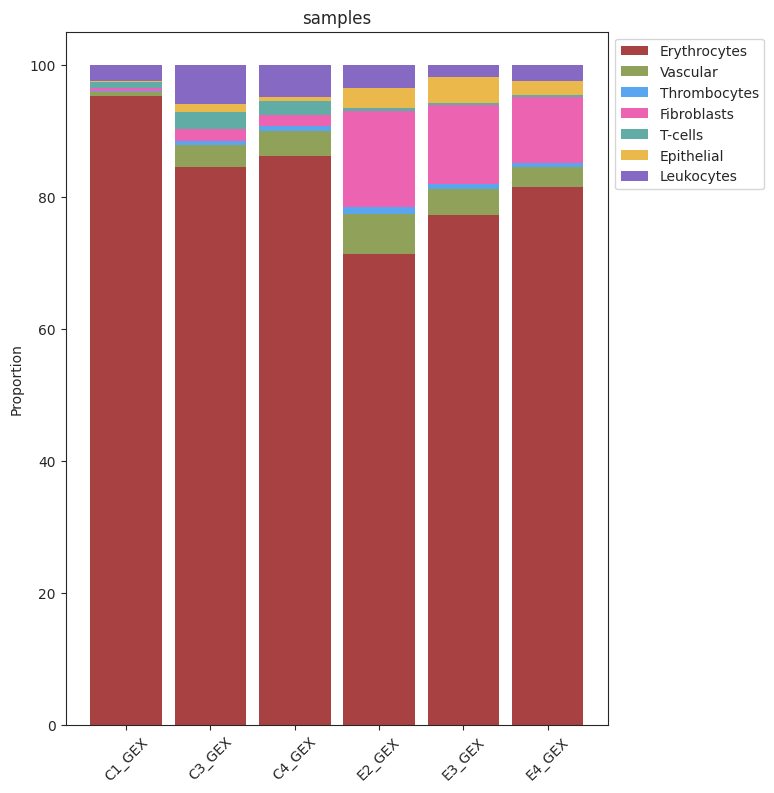

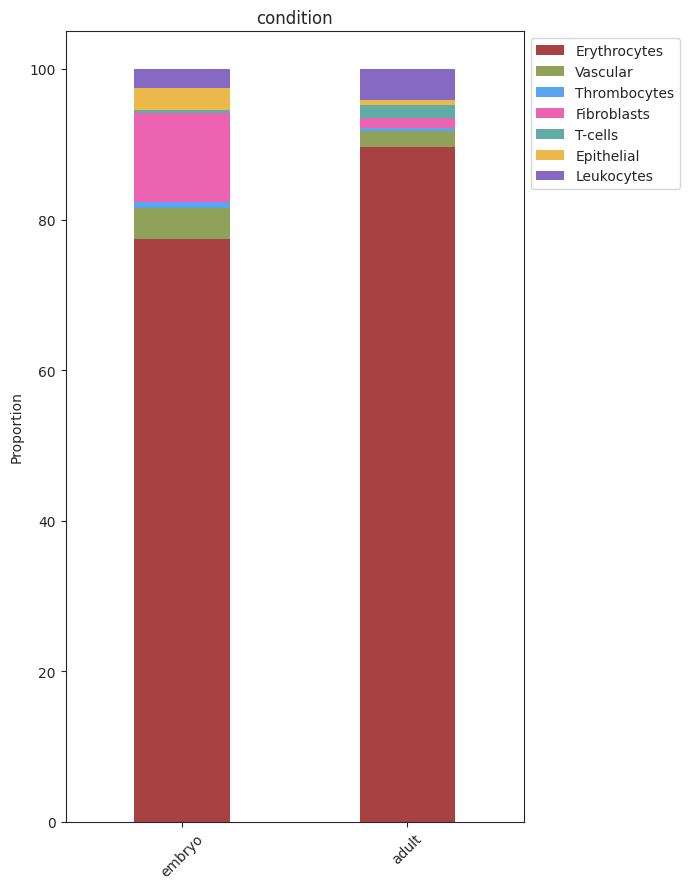

In [49]:
# Stacked barplot for each sample


palette={"Erythrocytes": "#A84242", 
                   "T-cells": "#61ADA5", 
                   "Thrombocytes": "#59A5F0", 
                   "Epithelial": "#EBB84B", 
                   "Fibroblasts": "#EB63B1", 
                   "Vascular": "#90A15A", 
                   "Leukocytes": "#8669c2"}

color_list = [palette[ct] for ct in reordered_data.var_names]
cmap_custom = ListedColormap(color_list)

viz.stacked_barplot(reordered_data, cmap=cmap_custom, feature_name="samples")
plt.show()

matplotlib.rcParams["figure.figsize"] = (7.0, 9.0)

# Stacked barplot for the levels of "Condition"
ax = viz.stacked_barplot(reordered_data, cmap=cmap_custom, feature_name="condition")

# Shrink bars to create gaps between them
for bar in ax.patches:
    current_width = bar.get_width()
    new_width = current_width * 0.5        # adjust 0.6 to taste
    diff = current_width - new_width
    bar.set_width(new_width)
    bar.set_x(bar.get_x() + diff / 2)     # re-center on original x position

plt.tight_layout()
plt.show()

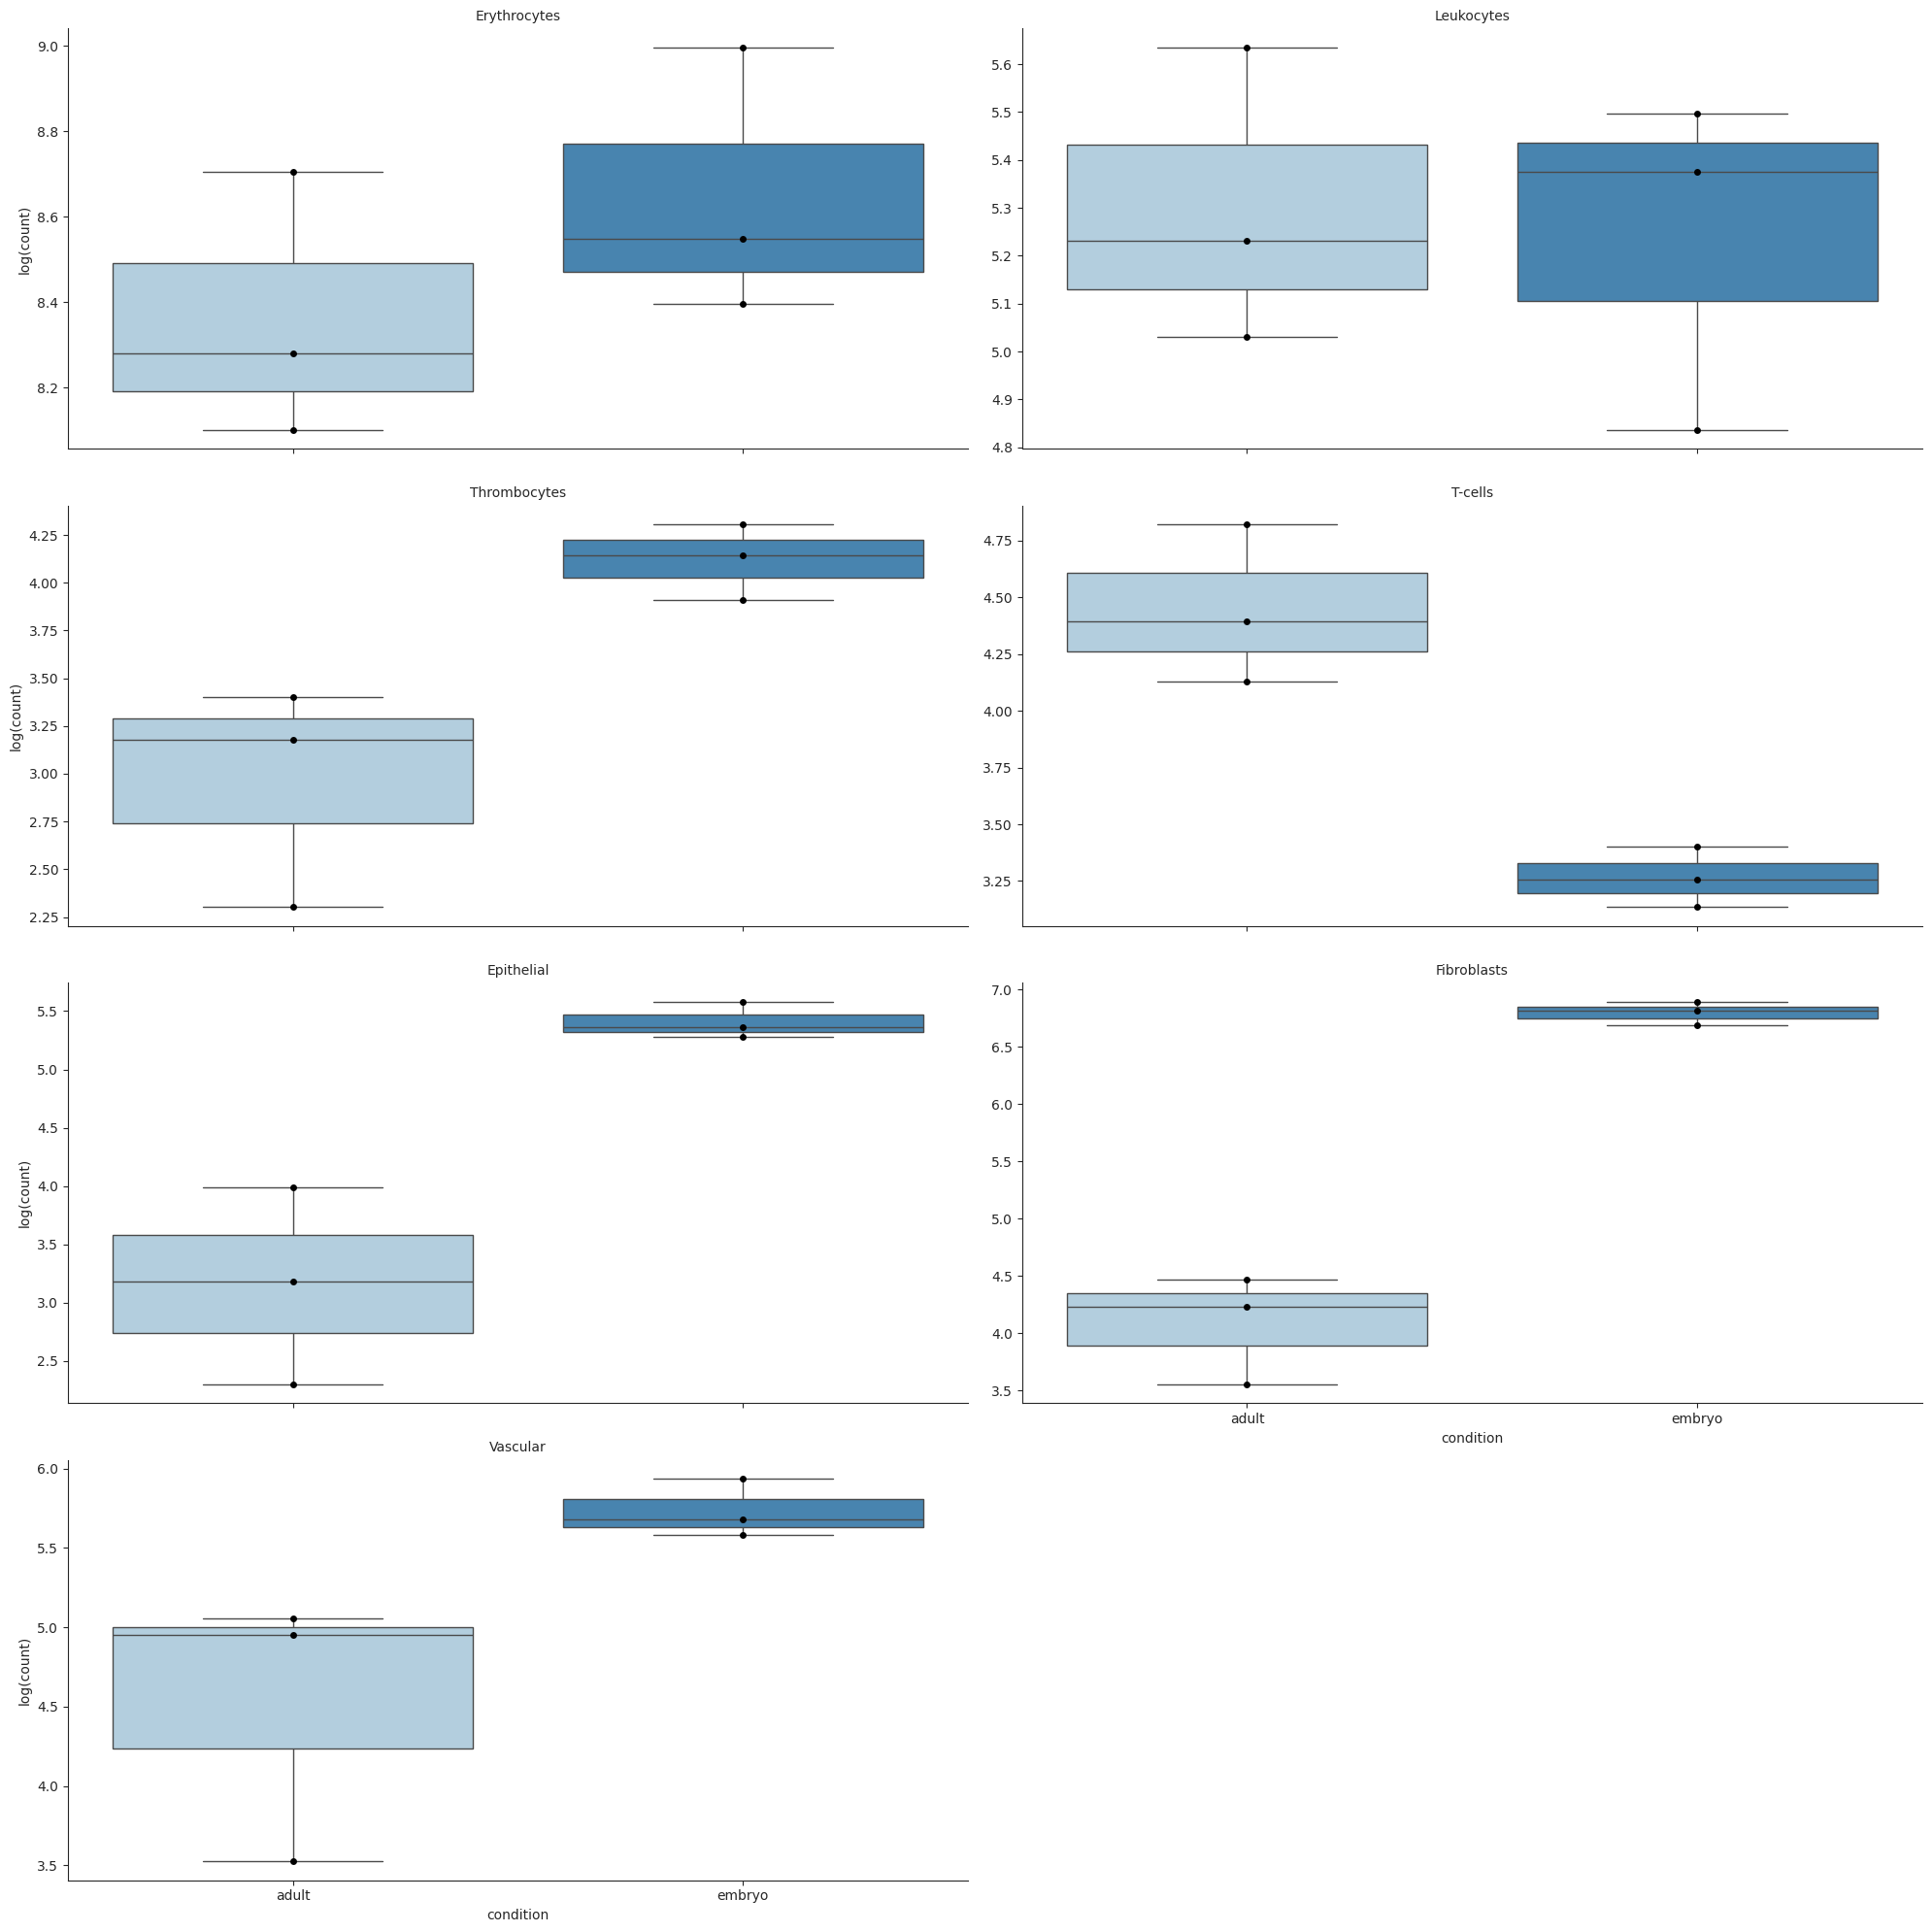

In [15]:
# Grouped boxplots. Facets, log scale, added dots and custom color palette.
viz.boxplots(
    data,
    feature_name="condition",
    plot_facets=True,
    y_scale="log",
    add_dots=True,
)
plt.show()

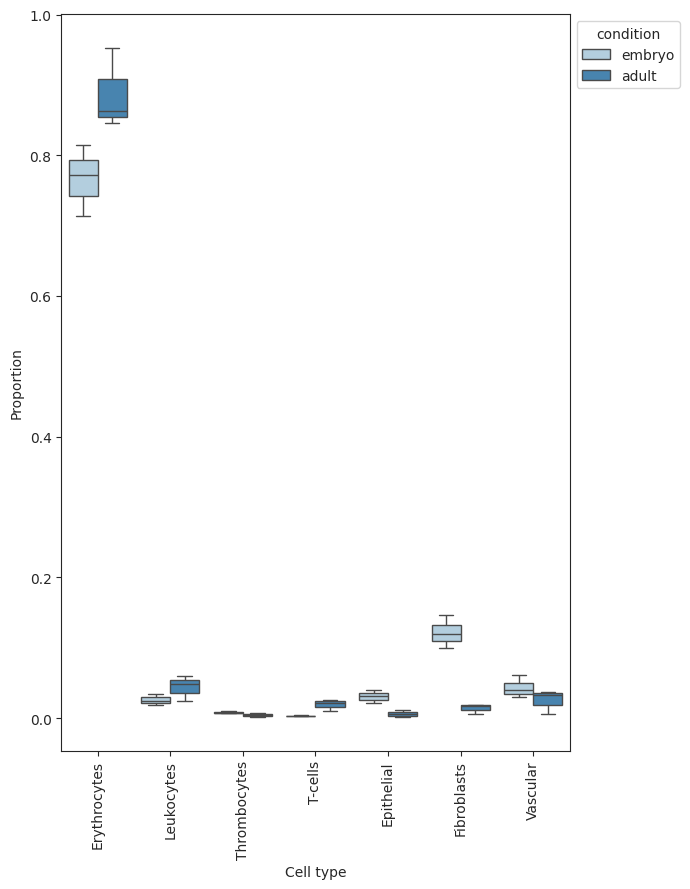

In [16]:
# Grouped boxplots. No facets, relative abundance, no dots.
viz.boxplots(
    data,
    feature_name="condition",
    plot_facets=False,
    y_scale="relative",
    add_dots=False,
)
plt.show()